# ISOMIGA AD coloc protective LINCS matching

This notebook summarizes preliminary drug-prioritization data for ISOMIGA microglia eQTL colocalizations with AD GWAS. The protective expression direction is inferred from the signs of the AD GWAS SNP beta and eQTL SNP beta: same sign means increased expression tracks AD risk, opposite sign means increased expression tracks protection.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from plotnine import *

DATA = Path("../data/processed")
FIG = Path("../results/figures")
FIG.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 80)

## Protective expression targets

In [2]:
targets = pd.read_csv(DATA / "protective_expression_targets.tsv", sep="\t")
gene_targets = pd.read_csv(DATA / "protective_expression_gene_summary.tsv", sep="\t")
coverage_path = DATA / "lincs_target_gene_coverage.tsv"
coverage = pd.read_csv(coverage_path, sep="\t") if coverage_path.exists() else None

print(f"High-H4 coloc target rows: {len(targets):,}")
print(f"Unique genes: {gene_targets['gene_name'].nunique():,}")
print(gene_targets['protective_direction_label'].value_counts(dropna=False))
display(gene_targets[[
    "gene_name", "protective_direction_label", "max_h4", "max_gwas_z_abs",
    "mr_ivw_beta", "mr_ivw_se", "mr_ivw_p", "n_coloc"
]].head(20))

High-H4 coloc target rows: 52
Unique genes: 27
protective_direction_label
decrease    20
increase     7
Name: count, dtype: int64


,gene_name,protective_direction_label,max_h4,max_gwas_z_abs,mr_ivw_beta,mr_ivw_se,mr_ivw_p,n_coloc
0,EPHA1-AS1,decrease,1.000000,14.408701,0.850789,0.056306,1.387442e-51,2
1,ZYX,decrease,0.999999,6.876577,0.804887,0.110458,3.173557e-13,2
2,BIN1,decrease,0.999914,5.939106,1.000000,0.128566,7.363545e-15,4
3,TAS2R60,decrease,0.999892,4.508150,0.768850,0.215369,3.570888e-04,1
4,RP11-960L18.1,decrease,0.999122,7.867841,0.944621,0.119621,2.862657e-15,2
5,CYP27C1,decrease,0.998687,5.199737,0.985452,0.133527,1.581219e-13,4
6,RASGEF1C,decrease,0.997078,7.232114,1.000000,0.141923,1.840191e-12,2
7,novelGene_813,decrease,0.997069,7.847131,1.000000,0.180243,2.888530e-08,1
8,AC093673.5,decrease,0.996383,4.284983,0.843363,0.198921,2.238271e-05,2
9,PLCG2_RP11-960L18.1_RN7SKP176,increase,0.993119,4.778005,-0.787318,0.393737,4.554307e-02,1


/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 5 x 3 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/target_direction_counts.png


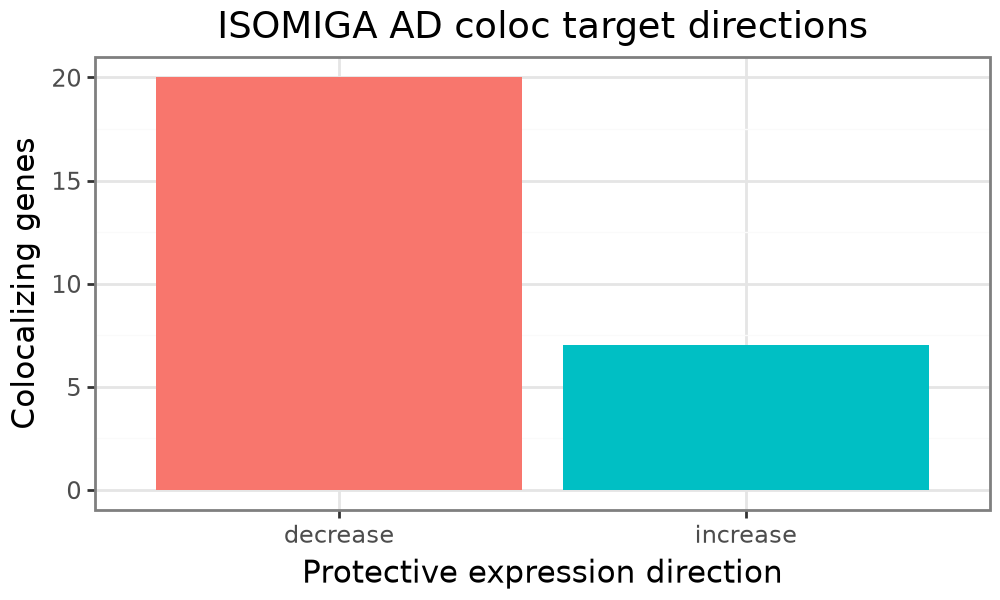

In [3]:
p = (
    ggplot(gene_targets, aes("protective_direction_label", fill="protective_direction_label"))
    + geom_bar(show_legend=False)
    + labs(x="Protective expression direction", y="Colocalizing genes", title="ISOMIGA AD coloc target directions")
    + theme_bw()
    + theme(figure_size=(5, 3))
)
p.save(FIG / "target_direction_counts.png", dpi=300)
p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 7 x 6 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_coloc_targets.png


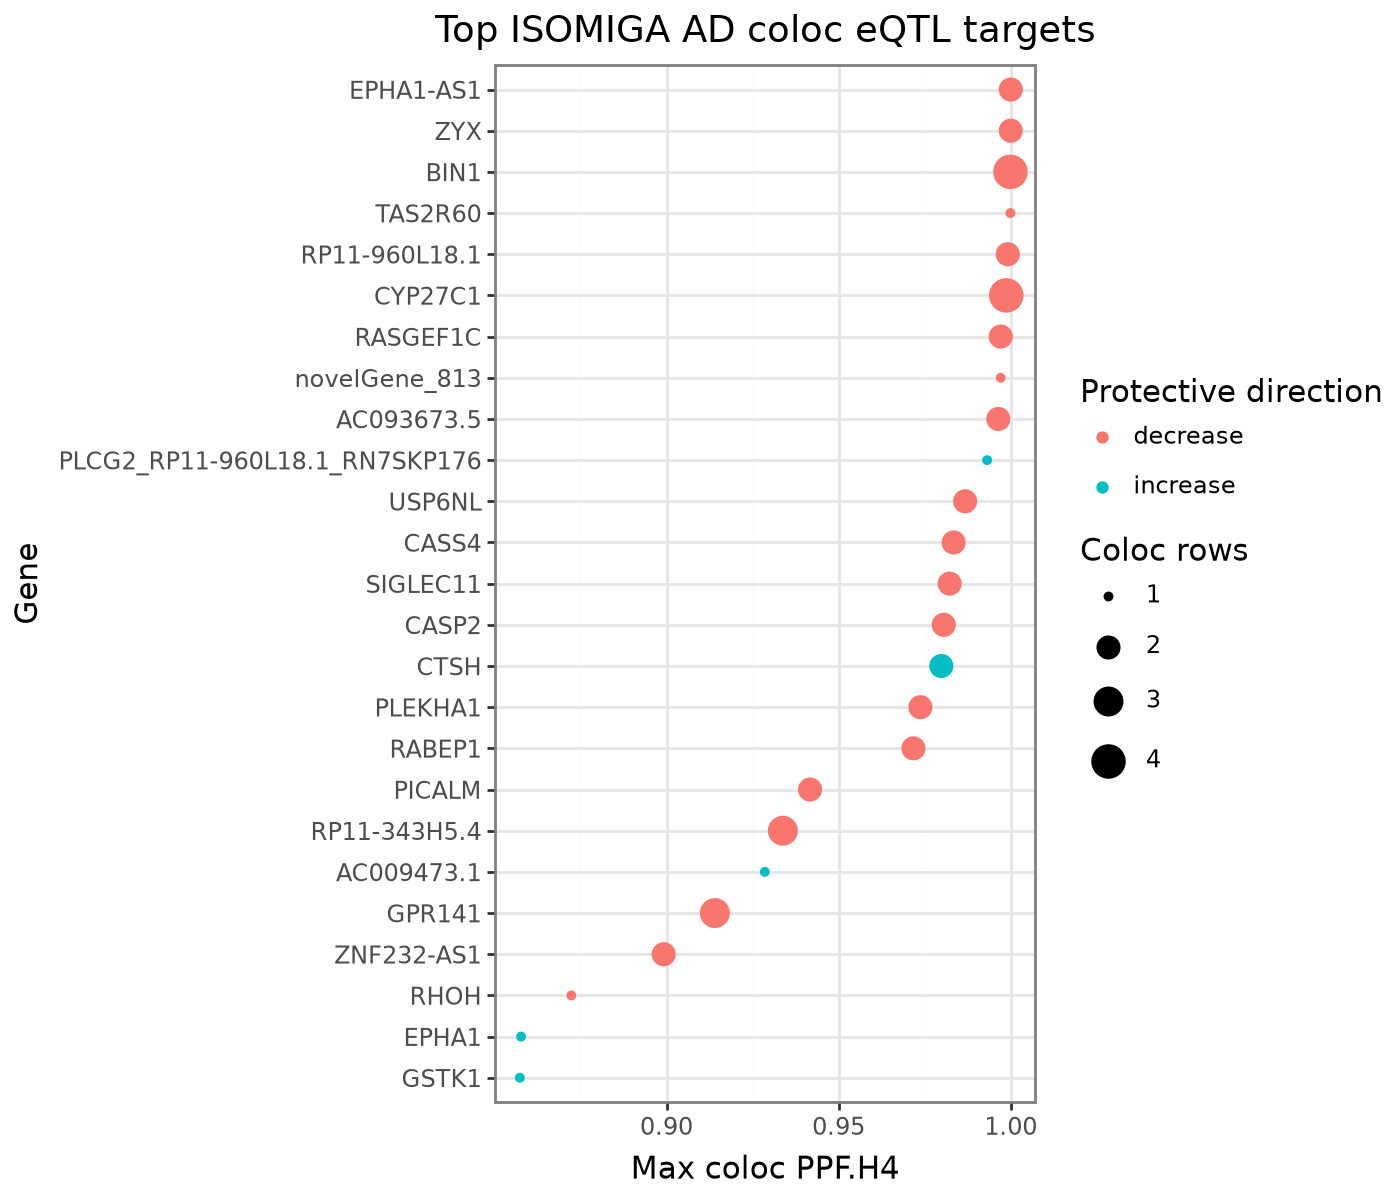

In [4]:
top_targets = (
    gene_targets.sort_values(["max_h4", "abs_protective_score"], ascending=False)
    .head(25)
    .assign(gene_name=lambda x: pd.Categorical(x["gene_name"], categories=x["gene_name"][::-1], ordered=True))
)
p = (
    ggplot(top_targets, aes("max_h4", "gene_name", color="protective_direction_label", size="n_coloc"))
    + geom_point()
    + labs(x="Max coloc PPF.H4", y="Gene", color="Protective direction", size="Coloc rows", title="Top ISOMIGA AD coloc eQTL targets")
    + theme_bw()
    + theme(figure_size=(7, 6))
)
p.save(FIG / "top_coloc_targets.png", dpi=300)
p

## LINCS target coverage

In [5]:
if coverage is None:
    print("Run scripts/extract_lincs_thp1_targets.py to produce LINCS target coverage.")
else:
    display(coverage['in_lincs'].value_counts(dropna=False))
    display(coverage.sort_values(['in_lincs', 'gene_name'], ascending=[True, True]).head(30))

in_lincs
False    14
True     13
Name: count, dtype: int64

,gene_name,gene_id,in_lincs
0,AC009473.1,NaN,False
1,AC093673.5,NaN,False
6,CYP27C1,NaN,False
8,EPHA1-AS1,NaN,False
9,GPR141,NaN,False
12,PLCG2_RP11-960L18.1_RN7SKP176,NaN,False
16,RASGEF1C,NaN,False
18,RP11-343H5.4,NaN,False
19,RP11-661A12.8,NaN,False
20,RP11-960L18.1,NaN,False


## THP1 drug scores

In [6]:
drug_scores_path = DATA / "lincs_thp1_protective_drug_scores.tsv"
drug_gene_path = DATA / "lincs_thp1_protective_drug_gene_scores.tsv"
if drug_scores_path.exists() and drug_gene_path.exists():
    drug_scores = pd.read_csv(drug_scores_path, sep="\t")
    drug_gene = pd.read_csv(drug_gene_path, sep="\t")
    display(drug_scores.head(25))
else:
    drug_scores = None
    drug_gene = None
    print("Run scripts/run_pipeline.sh through LINCS extraction/scoring to populate drug score files.")

,pert_id,pert_iname,n_target_genes,n_protective_genes,n_strong_protective_genes,n_opposing_genes,mean_protective_push_z,median_protective_push_z,summed_weighted_push,total_weight,mean_target_mr_ivw_beta,median_target_mr_ivw_beta,min_target_mr_ivw_p,min_n_signatures,total_gene_signatures,weighted_mean_protective_push_z,fraction_genes_protective
0,BRD-K04623885,BIBR-1532,13,10,6,3,0.710964,0.457883,14.771234,24.0,0.468112,0.804887,1.000720e-15,1,13,0.615468,0.769231
1,BRD-K41895714,AS-605240,13,6,5,7,-0.140969,-0.156459,3.407768,24.0,0.468112,0.804887,1.000720e-15,1,13,0.141990,0.461538
2,BRD-A77216878,manumycin-a,13,6,5,7,-0.329792,-0.833900,-3.758800,24.0,0.468112,0.804887,1.000720e-15,1,13,-0.156617,0.461538
3,BRD-K67566344,KU-0063794,13,6,5,7,-0.446592,-1.327550,-10.921749,24.0,0.468112,0.804887,1.000720e-15,1,13,-0.455073,0.461538
4,BRD-K60623809,SU-11652,13,6,5,7,-1.039500,-1.088500,-13.442700,24.0,0.468112,0.804887,1.000720e-15,1,13,-0.560113,0.461538
5,BRD-K09635314,m-3M3FBS,13,5,5,8,-0.962198,-1.682019,-31.976964,24.0,0.468112,0.804887,1.000720e-15,1,13,-1.332374,0.384615
6,BRD-A35588707,teniposide,13,7,4,6,0.242831,0.095150,8.545150,24.0,0.468112,0.804887,1.000720e-15,1,13,0.356048,0.538462
7,BRD-A13122391,triptolide,13,9,4,4,0.372055,0.326528,7.019161,24.0,0.468112,0.804887,1.000720e-15,1,13,0.292465,0.692308
8,BRD-K15409150,penfluridol,13,8,4,5,0.265885,0.581300,5.800600,24.0,0.468112,0.804887,1.000720e-15,1,13,0.241692,0.615385
9,BRD-K18190982,COT-10b,13,8,4,5,-0.024096,0.195400,-0.219799,24.0,0.468112,0.804887,1.000720e-15,1,13,-0.009158,0.615385


In [7]:
if drug_scores is not None:
    top_drugs = (
        drug_scores.head(20)
        .assign(pert_iname=lambda x: pd.Categorical(x["pert_iname"], categories=x["pert_iname"][::-1], ordered=True))
    )
    p = (
        ggplot(top_drugs, aes("weighted_mean_protective_push_z", "pert_iname"))
        + geom_col(fill="#3b6ea8")
        + geom_point(aes(size="n_protective_genes"), color="#111111")
        + labs(x="Weighted mean protective push z", y="Compound", size="Protective genes", title="Top THP1 LINCS compounds by protective expression push")
        + theme_bw()
        + theme(figure_size=(7, 6))
    )
    p.save(FIG / "top_lincs_protective_drugs.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 7 x 6 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_lincs_protective_drugs.png


In [8]:
if drug_gene is not None and drug_scores is not None:
    selected = drug_scores.head(12)[["pert_id", "pert_iname"]]
    heat = drug_gene.merge(selected, on=["pert_id", "pert_iname"])
    gene_order = (
        heat.groupby("gene_name")["max_h4"].max().sort_values(ascending=False).index.tolist()
    )
    heat["gene_name"] = pd.Categorical(heat["gene_name"], categories=gene_order[::-1], ordered=True)
    heat["pert_iname"] = pd.Categorical(heat["pert_iname"], categories=selected["pert_iname"][::-1], ordered=True)
    p = (
        ggplot(heat, aes("pert_iname", "gene_name", fill="protective_push_z"))
        + geom_tile(color="white")
        + scale_fill_gradient2(low="#9c2f2f", mid="#f7f7f7", high="#2f7d4f", midpoint=0)
        + labs(x="Compound", y="Target gene", fill="Protective push z", title="Per-gene protective push for top compounds")
        + theme_bw()
        + theme(figure_size=(8, max(4, 0.25 * len(gene_order))), axis_text_x=element_text(rotation=45, ha="right"))
    )
    p.save(FIG / "top_drug_gene_protective_push_heatmap.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_drug_gene_protective_push_heatmap.png


## Export prelim tables

In [9]:
if drug_scores is not None:
    cols = ["pert_iname", "n_target_genes", "n_protective_genes", "n_strong_protective_genes", "weighted_mean_protective_push_z", "fraction_genes_protective", "min_n_signatures"]
    prelim = drug_scores.loc[:, cols].head(50)
    prelim.to_csv(DATA / "prelim_top_lincs_thp1_protective_drugs.tsv", sep="\t", index=False)
    display(prelim.head(20))

,pert_iname,n_target_genes,n_protective_genes,n_strong_protective_genes,weighted_mean_protective_push_z,fraction_genes_protective,min_n_signatures
0,BIBR-1532,13,10,6,0.615468,0.769231,1
1,AS-605240,13,6,5,0.141990,0.461538,1
2,manumycin-a,13,6,5,-0.156617,0.461538,1
3,KU-0063794,13,6,5,-0.455073,0.461538,1
4,SU-11652,13,6,5,-0.560113,0.461538,1
5,m-3M3FBS,13,5,5,-1.332374,0.384615,1
6,teniposide,13,7,4,0.356048,0.538462,1
7,triptolide,13,9,4,0.292465,0.692308,1
8,penfluridol,13,8,4,0.241692,0.615385,1
9,COT-10b,13,8,4,-0.009158,0.615385,1


## MOA/target annotations and selected-drug matches

In [10]:
annotated_path = DATA / "prelim_top_lincs_thp1_protective_drugs_annotated.tsv"
if annotated_path.exists():
    annotated = pd.read_csv(annotated_path, sep="\t")
    display(annotated[[
        "pert_iname", "moa", "target", "clinical_phase", "annotation_source",
        "n_protective_genes", "n_strong_protective_genes",
        "weighted_mean_protective_push_z", "median_target_mr_ivw_beta",
        "min_target_mr_ivw_p", "biology_note"
    ]].head(20))
else:
    print("Run scripts/annotate_prioritized_drugs.py to create the annotated top-drug table.")

,pert_iname,moa,target,clinical_phase,annotation_source,n_protective_genes,n_strong_protective_genes,weighted_mean_protective_push_z,median_target_mr_ivw_beta,min_target_mr_ivw_p,biology_note
0,BIBR-1532,telomerase inhibitor,TERT/telomerase,Preclinical/tool,manual: telomerase inhibitor literature/opnMe,10,6,0.615468,0.804887,1.000720e-15,"Strongest transcriptomic match; tool telomerase inhibitor, so prioritize as ..."
1,AS-605240,PI3K-gamma inhibitor,PIK3CG,Preclinical/tool,manual: PI3K-gamma inhibitor literature,6,5,0.141990,0.804887,1.000720e-15,Interesting for microglia because PI3K-gamma regulates myeloid inflammatory ...
2,manumycin-a,farnesyltransferase/Ras pathway inhibitor,FNTA|FNTB; Ras pathway,Preclinical/tool,manual: chemical biology annotation,6,5,-0.156617,0.804887,1.000720e-15,Several strong pushes but overall weighted opposition; useful as a Ras/isopr...
3,KU-0063794,mTOR inhibitor,MTOR,Preclinical/tool,manual: vendor/chemical biology annotation,6,5,-0.455073,0.804887,1.000720e-15,Multiple strong gene-level pushes but negative weighted score; keep as a pat...
4,SU-11652,multi-kinase inhibitor,VEGFR/PDGFR/KIT-family kinases,Preclinical/tool,manual: chemical biology annotation,6,5,-0.560113,0.804887,1.000720e-15,Strong pushes are offset by weighted opposing genes.
5,m-3M3FBS,phospholipase activator,PLCB2|PLCB3|PLCD1|PLCG1|PLCG2,Preclinical,Broad Repurposing Hub,5,5,-1.332374,0.804887,1.000720e-15,NaN
6,teniposide,topoisomerase inhibitor,TOP2A|TOP2B,Launched,Broad Repurposing Hub,7,4,0.356048,0.804887,1.000720e-15,NaN
7,triptolide,XPB/TFIIH inhibitor; broad transcriptional/NF-kB suppressive effects,ERCC3/XPB; TFIIH complex,Phase 3,manual: XPB/TFIIH target literature,9,4,0.292465,0.804887,1.000720e-15,"Strong multi-gene protective-direction match and anti-inflammatory biology, ..."
8,penfluridol,T-type calcium channel blocker,CACNA1G,Launched,Broad Repurposing Hub,8,4,0.241692,0.804887,1.000720e-15,NaN
9,COT-10b,not annotated,not annotated,not annotated,not annotated,8,4,-0.009158,0.804887,1.000720e-15,NaN


The selected-drug figures are written to `results/figures/`:

- `selected_promising_drug_gene_match_bars.png`
- `selected_promising_drug_genetics_lincs_scatter.png`
- `selected_promising_drug_summary.png`

## LINCS z-score versus naive MR effect

In [11]:
if drug_scores is not None and drug_gene is not None:
    top_for_mr = drug_scores.head(8)[["pert_id", "pert_iname"]].copy()
    mr_match = drug_gene.merge(top_for_mr, on=["pert_id", "pert_iname"], how="inner")
    mr_match = mr_match.dropna(subset=["mr_ivw_beta", "mr_ivw_se", "mean_z"]).copy()
    mr_match["mr_beta_lo"] = mr_match["mr_ivw_beta"] - 1.96 * mr_match["mr_ivw_se"]
    mr_match["mr_beta_hi"] = mr_match["mr_ivw_beta"] + 1.96 * mr_match["mr_ivw_se"]
    mr_match["drug_match"] = np.where(mr_match["protective_push_z"] > 0, "protective", "opposing")
    mr_match["pert_iname"] = pd.Categorical(
        mr_match["pert_iname"],
        categories=top_for_mr["pert_iname"].tolist(),
        ordered=True,
    )
    display(mr_match[[
        "pert_iname", "gene_name", "mean_z", "mr_ivw_beta", "mr_ivw_se",
        "protective_direction_label", "protective_push_z"
    ]].sort_values(["pert_iname", "gene_name"]).head(40))
else:
    mr_match = None
    print("Run the scoring step first.")

,pert_iname,gene_name,mean_z,mr_ivw_beta,mr_ivw_se,protective_direction_label,protective_push_z
24,BIBR-1532,BIN1,0.526100,1.000000,0.128566,decrease,-0.526100
13,BIBR-1532,CASP2,-2.297865,1.000000,0.223710,decrease,2.297865
16,BIBR-1532,CASS4,-1.473255,0.816400,0.114825,decrease,1.473255
21,BIBR-1532,CTSH,0.273137,-0.653192,0.116413,increase,0.273137
25,BIBR-1532,EPHA1,-0.875633,-0.277406,0.118801,increase,-0.875633
14,BIBR-1532,GSTK1,1.748803,-0.426266,0.102608,increase,1.748803
23,BIBR-1532,PICALM,0.181233,0.985810,0.242171,decrease,-0.181233
20,BIBR-1532,PLEKHA1,-0.312305,0.971864,0.121078,decrease,0.312305
19,BIBR-1532,PSMC3,0.457883,-0.619249,0.308844,increase,0.457883
18,BIBR-1532,RABEP1,-1.127788,0.755559,0.137653,decrease,1.127788


In [12]:
if mr_match is not None and len(mr_match):
    p = (
        ggplot(mr_match, aes("mr_ivw_beta", "mean_z", color="drug_match"))
        + geom_hline(yintercept=0, color="#555555", size=0.35)
        + geom_vline(xintercept=0, color="#555555", size=0.35)
        + geom_segment(aes(x="mr_beta_lo", xend="mr_beta_hi", y="mean_z", yend="mean_z"), alpha=0.6)
        + geom_point(aes(size="max_h4"), alpha=0.9)
        + geom_text(aes(label="gene_name"), nudge_y=0.12, size=6.5, show_legend=False)
        + facet_wrap("~pert_iname", ncol=2)
        + scale_color_manual(values={"protective": "#2f7d4f", "opposing": "#9c2f2f"})
        + labs(
            x="Naive MR beta for increased expression on AD risk (IVW; horizontal bars = 95% CI)",
            y="LINCS THP1 mean z-score",
            color="Drug push",
            size="Max PPF.H4",
            title="Top-drug LINCS effects versus naive MR genetic effects",
        )
        + theme_bw()
        + theme(figure_size=(11, 9))
    )
    p.save(FIG / "top_drugs_lincs_z_vs_mr_beta.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 9 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_drugs_lincs_z_vs_mr_beta.png


In [13]:
if mr_match is not None and len(mr_match):
    # Protective matching view: negative values mean the drug pushes opposite to the genetically protective direction.
    signed_mr = mr_match.copy()
    signed_mr["risk_aligned_lincs_z"] = signed_mr["mean_z"] * np.sign(signed_mr["mr_ivw_beta"])
    p = (
        ggplot(signed_mr, aes("mr_ivw_beta", "risk_aligned_lincs_z", color="drug_match"))
        + geom_hline(yintercept=0, color="#555555", size=0.35)
        + geom_vline(xintercept=0, color="#555555", size=0.35)
        + geom_segment(aes(x="mr_beta_lo", xend="mr_beta_hi", y="risk_aligned_lincs_z", yend="risk_aligned_lincs_z"), alpha=0.6)
        + geom_point(aes(size="max_h4"), alpha=0.9)
        + geom_text(aes(label="gene_name"), nudge_y=0.12, size=6.5, show_legend=False)
        + facet_wrap("~pert_iname", ncol=2)
        + scale_color_manual(values={"protective": "#2f7d4f", "opposing": "#9c2f2f"})
        + labs(
            x="Naive MR beta for increased expression on AD risk (IVW; horizontal bars = 95% CI)",
            y="LINCS z-score aligned to MR risk direction",
            color="Drug push",
            size="Max PPF.H4",
            title="Top-drug expression effects relative to genetically inferred risk direction",
        )
        + theme_bw()
        + theme(figure_size=(11, 9))
    )
    p.save(FIG / "top_drugs_lincs_z_vs_mr_beta_risk_aligned.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 9 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_drugs_lincs_z_vs_mr_beta_risk_aligned.png


## Display saved LINCS-vs-MR figures

top_drugs_lincs_z_vs_mr_beta.png


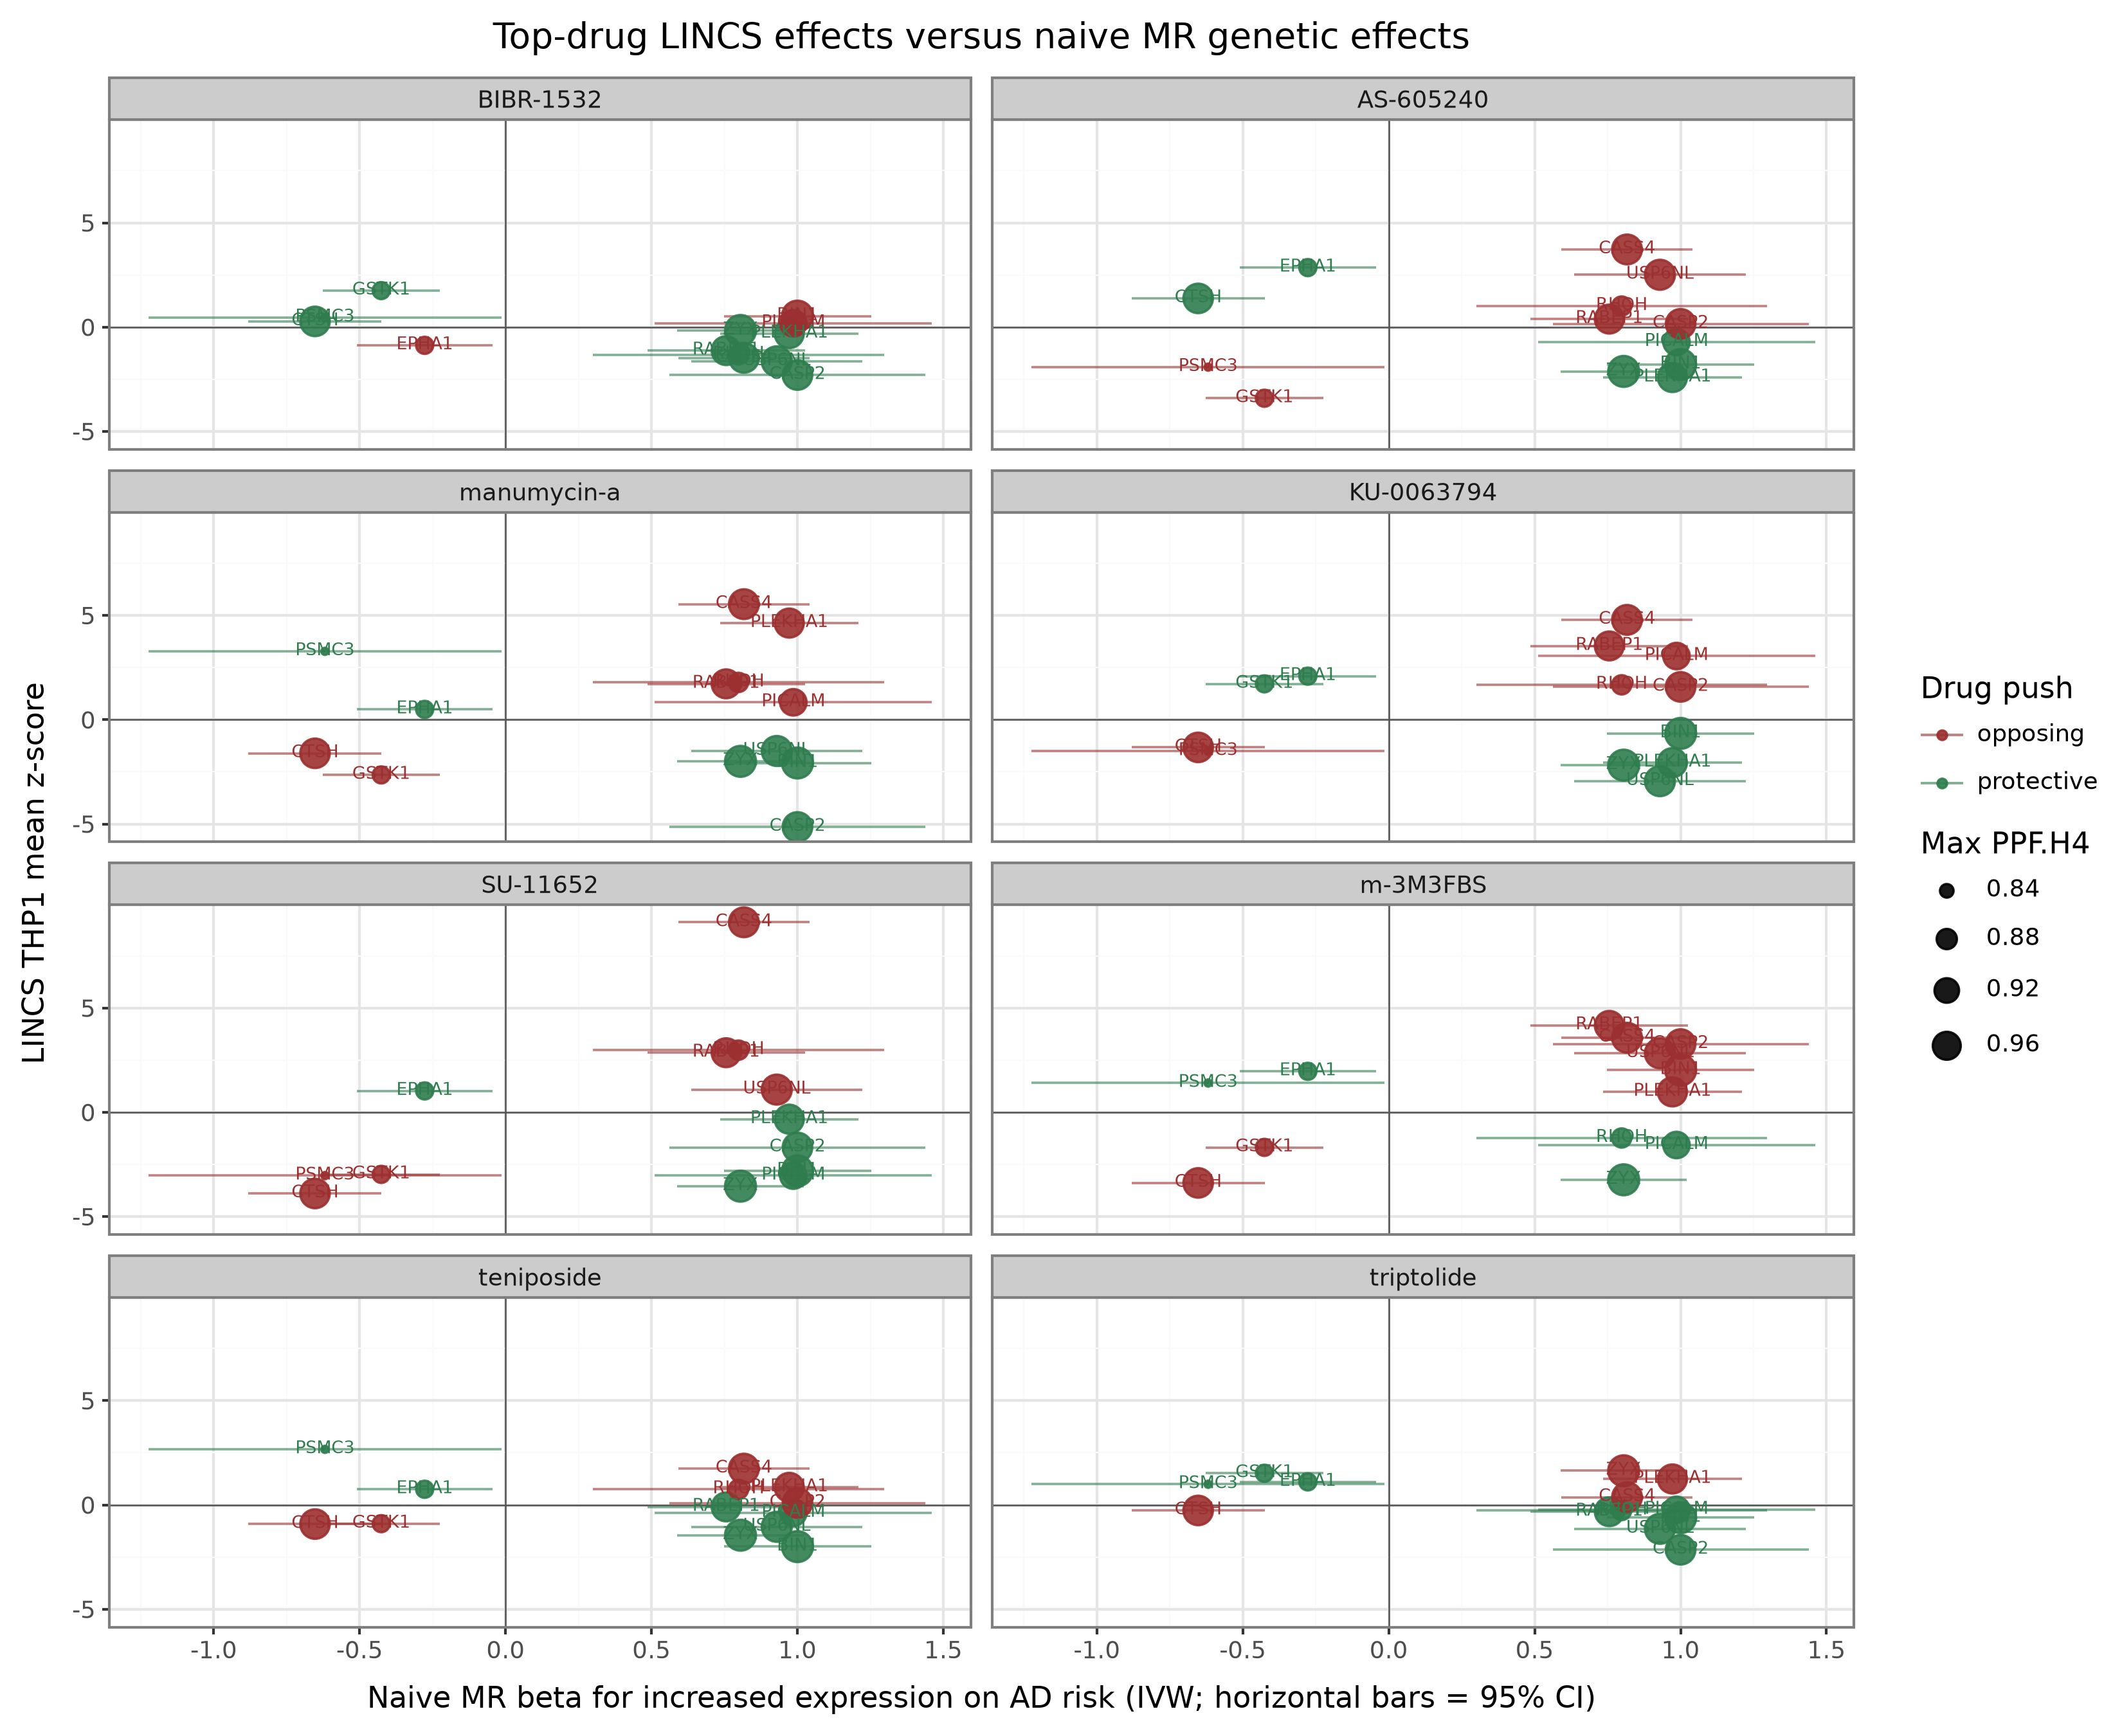

top_drugs_lincs_z_vs_mr_beta_risk_aligned.png


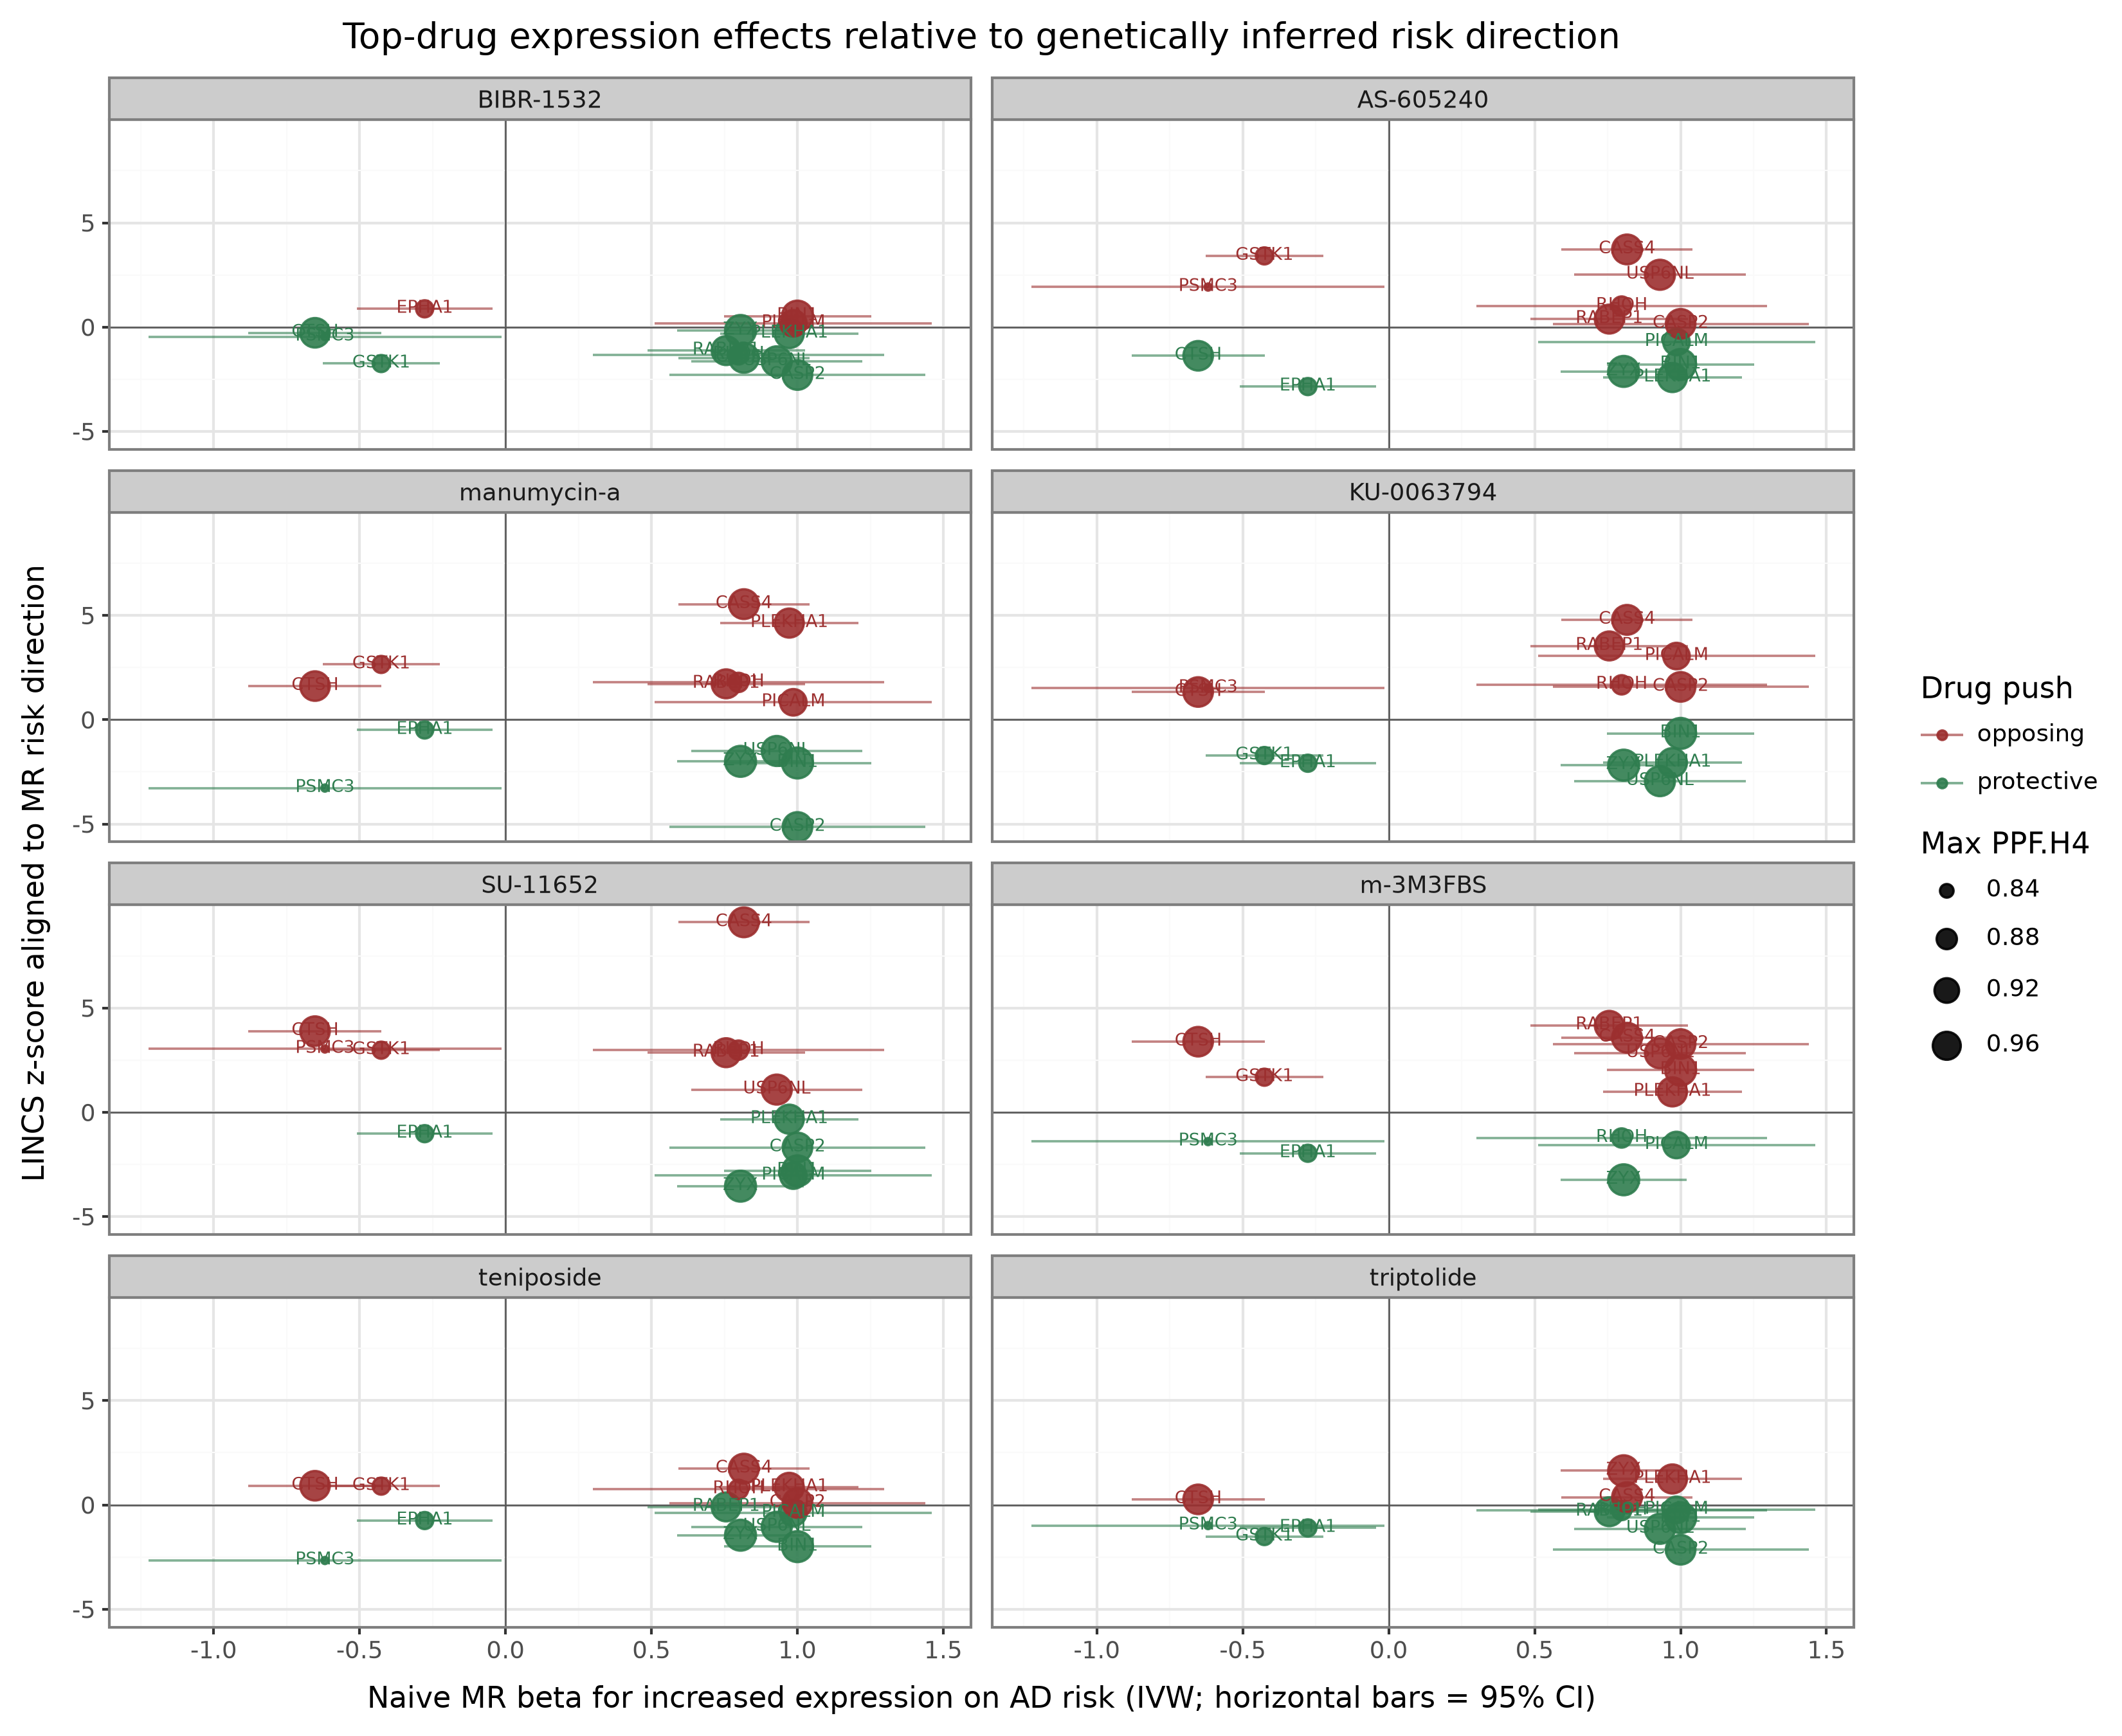

In [14]:
from IPython.display import Image, display

for fig_name in [
    "top_drugs_lincs_z_vs_mr_beta.png",
    "top_drugs_lincs_z_vs_mr_beta_risk_aligned.png",
]:
    fig_path = FIG / fig_name
    if fig_path.exists():
        print(fig_name)
        display(Image(filename=str(fig_path)))
    else:
        print(f"Missing: {fig_path}")

## MR-aware LINCS ranking

This section uses MR beta magnitude and MR standard error, not just the sign. For each drug-gene pair, positive values indicate that the drug-induced expression change is predicted to reduce AD risk:

`mr_lincs_effect = -LINCS_mean_z * mr_ivw_beta`

The precision-weighted score is:

`mr_lincs_precision_match = -LINCS_mean_z * (mr_ivw_beta / mr_ivw_se)`

In [15]:
mr_drug_path = DATA / "lincs_thp1_mr_lincs_drug_scores.tsv"
mr_gene_path = DATA / "lincs_thp1_mr_lincs_drug_gene_scores.tsv"
if mr_drug_path.exists() and mr_gene_path.exists():
    mr_drug = pd.read_csv(mr_drug_path, sep="\t")
    mr_gene = pd.read_csv(mr_gene_path, sep="\t")
    display(mr_drug[[
        "pert_iname", "n_positive_mr_effect", "n_strong_precision_match",
        "mean_mr_lincs_effect", "sum_precision_match", "fraction_positive_mr_effect",
        "moa", "target"
    ]].head(30))
else:
    mr_drug = None
    mr_gene = None
    print("Run scripts/score_mr_lincs_drugs.py first.")

,pert_iname,n_positive_mr_effect,n_strong_precision_match,mean_mr_lincs_effect,sum_precision_match,fraction_positive_mr_effect,moa,target
0,BIBR-1532,10,7,0.587200,47.813654,0.769231,telomerase inhibitor,TERT/telomerase
1,BML-259,8,7,0.453994,33.332377,0.615385,not annotated,not annotated
2,BRD-K08451418,9,5,0.252738,27.915604,0.692308,not annotated,not annotated
3,FTI-276,9,7,0.284388,27.446730,0.692308,not annotated,not annotated
4,TW-37,9,6,0.294073,25.708697,0.692308,BCL inhibitor,BCL2|BCL2L1|MCL1
5,thioridazine,7,6,0.249561,23.687581,0.538462,dopamine receptor antagonist,DRD1|DRD2|DRD3|DRD4|DRD5|HRH1|HTR1A|HTR2A|HTR2C|HTR6|HTR7
6,vemurafenib,9,7,0.238484,23.163589,0.692308,RAF inhibitor,BRAF|RAF1
7,PKCbeta-inhibitor,10,7,0.230823,22.456024,0.769231,not annotated,not annotated
8,fumonisin-b1,9,4,0.210075,21.831560,0.692308,not annotated,CERS1
9,MW-A1-12,9,6,0.220178,21.805875,0.692308,not annotated,not annotated


In [16]:
if mr_drug is not None:
    top_mr = mr_drug.head(25).copy()
    top_mr["pert_iname"] = pd.Categorical(top_mr["pert_iname"], categories=top_mr["pert_iname"][::-1], ordered=True)
    p = (
        ggplot(top_mr, aes("sum_precision_match", "pert_iname"))
        + geom_col(fill="#3b6ea8")
        + geom_point(aes(size="n_strong_precision_match"), color="#111111")
        + labs(
            x="Sum of MR precision-weighted LINCS match",
            y="Compound",
            size="Strong gene matches",
            title="Top THP1 drugs by MR-aware LINCS match",
        )
        + theme_bw()
        + theme(figure_size=(8, 7))
    )
    p.save(FIG / "top_mr_lincs_drug_scores.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 7 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_mr_lincs_drug_scores.png


In [17]:
if mr_gene is not None and mr_drug is not None:
    top_ids = mr_drug.head(8)[["pert_id", "pert_iname"]]
    drivers = mr_gene.merge(top_ids, on=["pert_id", "pert_iname"], how="inner")
    drivers = drivers.sort_values(["pert_iname", "mr_lincs_precision_match"], ascending=[True, False])
    display(drivers[[
        "pert_iname", "gene_name", "mean_z", "mr_ivw_beta", "mr_ivw_se",
        "mr_lincs_effect", "mr_lincs_precision_match"
    ]].groupby("pert_iname", group_keys=False).head(8))

,pert_iname,gene_name,mean_z,mr_ivw_beta,mr_ivw_se,mr_lincs_effect,mr_lincs_precision_match
0,BIBR-1532,CASS4,-1.473255,0.816400,0.114825,1.202766,10.474758
1,BIBR-1532,CASP2,-2.297865,1.000000,0.223710,2.297865,10.271627
2,BIBR-1532,USP6NL,-1.641788,0.929130,0.149916,1.525435,10.175293
3,BIBR-1532,GSTK1,1.748803,-0.426266,0.102608,0.745456,7.265052
4,BIBR-1532,RABEP1,-1.127788,0.755559,0.137653,0.852110,6.190269
...,...,...,...,...,...,...,...
94,vemurafenib,CTSH,0.625400,-0.653192,0.116413,0.408506,3.509112
95,vemurafenib,CASS4,-0.343600,0.816400,0.114825,0.280515,2.442976
96,vemurafenib,PSMC3,1.173350,-0.619249,0.308844,0.726595,2.352630
97,vemurafenib,GSTK1,0.516850,-0.426266,0.102608,0.220316,2.147150


In [18]:
if mr_gene is not None and mr_drug is not None:
    top_ids = mr_drug.head(8)[["pert_id", "pert_iname"]]
    plot_df = mr_gene.merge(top_ids, on=["pert_id", "pert_iname"], how="inner")
    plot_df["positive"] = np.where(plot_df["mr_lincs_effect"] > 0, "protective", "opposing")
    plot_df["pert_iname"] = pd.Categorical(plot_df["pert_iname"], categories=top_ids["pert_iname"].tolist(), ordered=True)
    p = (
        ggplot(plot_df, aes("mr_lincs_effect", "mr_lincs_precision_match", color="positive"))
        + geom_hline(yintercept=0, color="#555555", size=0.35)
        + geom_vline(xintercept=0, color="#555555", size=0.35)
        + geom_point(aes(size="max_h4"), alpha=0.9)
        + geom_text(aes(label="gene_name"), nudge_y=0.25, size=6.5, show_legend=False)
        + facet_wrap("~pert_iname", ncol=2)
        + scale_color_manual(values={"protective": "#2f7d4f", "opposing": "#9c2f2f"})
        + labs(
            x="MR-aware predicted protective effect: -LINCS_z * MR_beta",
            y="Precision-weighted match: -LINCS_z * MR_beta / MR_se",
            color="Gene-level match",
            size="Max PPF.H4",
            title="Gene drivers of top MR-aware LINCS drug matches",
        )
        + theme_bw()
        + theme(figure_size=(11, 9))
    )
    p.save(FIG / "top_mr_lincs_gene_driver_scatter.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 9 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_mr_lincs_gene_driver_scatter.png


## Heteroskedastic no-intercept MR-LINCS regression

For each drug, fit a weighted no-intercept regression across target genes:

`MR_beta_g = slope_drug * LINCS_z_drug,g + error_g`

with weights `1 / MR_se_g^2`. A protective drug should have a negative slope because it increases genes with negative MR beta and/or decreases genes with positive MR beta. Drugs are ranked by the one-sided p-value for `slope < 0`.

In [19]:
reg_drug_path = DATA / "lincs_thp1_mr_lincs_regression_drug_scores.tsv"
reg_gene_path = DATA / "lincs_thp1_mr_lincs_regression_gene_data.tsv"
if reg_drug_path.exists() and reg_gene_path.exists():
    reg_drug = pd.read_csv(reg_drug_path, sep="\t")
    reg_gene = pd.read_csv(reg_gene_path, sep="\t")
    display(reg_drug[[
        "pert_iname", "slope", "slope_se", "slope_z", "p_protective",
        "minus_log10_p_protective", "moa", "target"
    ]].head(40))
else:
    reg_drug = None
    reg_gene = None
    print("Run scripts/score_mr_lincs_regression.py first.")

,pert_iname,slope,slope_se,slope_z,p_protective,minus_log10_p_protective,moa,target
0,PKCbeta-inhibitor,-1.124253,0.079585,-14.126437,1.305107e-45,44.884354,not annotated,not annotated
1,BRD-K08451418,-0.817012,0.058478,-13.971264,1.167233e-44,43.932842,not annotated,not annotated
2,FTI-276,-0.830864,0.062864,-13.216912,3.504145e-40,39.455418,not annotated,not annotated
3,vemurafenib,-0.856225,0.067217,-12.738200,1.813323e-37,36.741525,RAF inhibitor,BRAF|RAF1
4,BML-259,-0.712719,0.058157,-12.255091,7.888587e-35,34.103001,not annotated,not annotated
5,MW-A1-12,-0.883863,0.072363,-12.214307,1.303565e-34,33.884867,not annotated,not annotated
6,fumonisin-b1,-0.817837,0.067549,-12.107317,4.830151e-34,33.316039,not annotated,CERS1
7,BIBR-1532,-0.385372,0.034037,-11.321986,5.106565e-30,29.291871,telomerase inhibitor,TERT/telomerase
8,ARG-CSC-91,-1.081524,0.095842,-11.284502,7.826305e-30,29.106443,not annotated,not annotated
9,PRL-3-inhibitor-I,-1.256499,0.111774,-11.241399,1.276516e-29,28.893974,not annotated,not annotated


In [20]:
if reg_drug is not None:
    top_reg = reg_drug.head(30).copy()
    top_reg["pert_iname"] = pd.Categorical(top_reg["pert_iname"], categories=top_reg["pert_iname"][::-1], ordered=True)
    p = (
        ggplot(top_reg, aes("minus_log10_p_protective", "pert_iname"))
        + geom_col(fill="#3b6ea8")
        + geom_point(aes(x="-slope"), color="#111111", size=1.8)
        + labs(
            x="-log10 one-sided p(slope < 0); black point = protective slope magnitude",
            y="Compound",
            title="Top drugs by heteroskedastic no-intercept MR-LINCS regression",
        )
        + theme_bw()
        + theme(figure_size=(8, 8))
    )
    p.save(FIG / "top_mr_lincs_regression_drug_scores.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 8 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_mr_lincs_regression_drug_scores.png


In [21]:
if reg_drug is not None and reg_gene is not None:
    top_ids = reg_drug.head(8)[["pert_id", "pert_iname", "slope", "slope_se", "p_protective"]]
    fit_df = reg_gene.merge(top_ids, on=["pert_id", "pert_iname"], how="inner")
    fit_df["mr_beta_lo"] = fit_df["mr_ivw_beta"] - 1.96 * fit_df["mr_ivw_se"]
    fit_df["mr_beta_hi"] = fit_df["mr_ivw_beta"] + 1.96 * fit_df["mr_ivw_se"]
    fit_df["protective_product"] = -fit_df["mean_z"] * fit_df["mr_ivw_beta"]
    fit_df["match"] = np.where(fit_df["protective_product"] > 0, "protective", "opposing")
    fit_df["pert_iname"] = pd.Categorical(fit_df["pert_iname"], categories=top_ids["pert_iname"].tolist(), ordered=True)
    display(fit_df[[
        "pert_iname", "gene_name", "mean_z", "mr_ivw_beta", "mr_ivw_se",
        "protective_product", "slope", "p_protective"
    ]].sort_values(["pert_iname", "protective_product"], ascending=[True, False]).groupby("pert_iname", group_keys=False).head(8))

,pert_iname,gene_name,mean_z,mr_ivw_beta,mr_ivw_se,protective_product,slope,p_protective
65,PKCbeta-inhibitor,PICALM,-0.849291,0.985810,0.242171,0.837240,-1.124253,1.305107e-45
66,PKCbeta-inhibitor,BIN1,-0.679848,1.000000,0.128566,0.679848,-1.124253,1.305107e-45
69,PKCbeta-inhibitor,PLEKHA1,-0.487499,0.971864,0.121078,0.473783,-1.124253,1.305107e-45
67,PKCbeta-inhibitor,RABEP1,-0.601349,0.755559,0.137653,0.454354,-1.124253,1.305107e-45
70,PKCbeta-inhibitor,CASS4,-0.462757,0.816400,0.114825,0.377795,-1.124253,1.305107e-45
...,...,...,...,...,...,...,...,...
4,BIBR-1532,RHOH,-1.330588,0.797916,0.254451,1.061698,-0.385372,5.106565e-30
5,BIBR-1532,RABEP1,-1.127788,0.755559,0.137653,0.852110,-0.385372,5.106565e-30
1,BIBR-1532,GSTK1,1.748803,-0.426266,0.102608,0.745456,-0.385372,5.106565e-30
7,BIBR-1532,PLEKHA1,-0.312305,0.971864,0.121078,0.303518,-0.385372,5.106565e-30


In [22]:
if reg_drug is not None and reg_gene is not None:
    line_df = reg_drug.head(8)[["pert_id", "pert_iname", "slope"]].copy()
    line_df["pert_iname"] = pd.Categorical(line_df["pert_iname"], categories=reg_drug.head(8)["pert_iname"].tolist(), ordered=True)
    p = (
        ggplot(fit_df, aes("mean_z", "mr_ivw_beta", color="match"))
        + geom_hline(yintercept=0, color="#555555", size=0.35)
        + geom_vline(xintercept=0, color="#555555", size=0.35)
        + geom_errorbar(aes(ymin="mr_beta_lo", ymax="mr_beta_hi"), width=0.08, alpha=0.45)
        + geom_point(aes(size="max_h4"), alpha=0.9)
        + geom_text(aes(label="gene_name"), nudge_y=0.08, size=6.2, show_legend=False)
        + geom_abline(data=line_df, mapping=aes(slope="slope"), intercept=0, linetype="dashed", color="#222222", inherit_aes=False)
        + facet_wrap("~pert_iname", ncol=2)
        + scale_color_manual(values={"protective": "#2f7d4f", "opposing": "#9c2f2f"})
        + labs(
            x="LINCS THP1 mean z-score",
            y="Naive MR beta for increased expression on AD risk",
            color="Gene-level product",
            size="Max PPF.H4",
            title="Weighted no-intercept MR-LINCS fits for top protective slopes",
        )
        + theme_bw()
        + theme(figure_size=(11, 9))
    )
    p.save(FIG / "top_mr_lincs_regression_fits.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_abline.py:72: PlotnineWarning: The 'intercept' and 'slope' when specified override the aes() mapping.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_abline.py:79: PlotnineWarning: The 'intercept' and 'slope' when specified override the data
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 9 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_mr_lincs_regression_fits.png
